In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [82]:
df=pd.read_csv(r"/amazon_products_sales_data_cleaned (1).csv")

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [84]:
len(df)

42675

In [85]:
df.isnull().sum()*100/len(df)

,0
product_title,0.000000
product_rating,2.399531
total_reviews,2.399531
purchased_last_month,24.630346
discounted_price,4.831869
original_price,4.831869
is_best_seller,0.000000
is_sponsored,0.000000
has_coupon,0.000000
buy_box_availability,34.336262


In [86]:
df.duplicated().sum()

np.int64(0)

# Action **items**9

In [87]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability',
       'delivery_date', 'sustainability_tags', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discount_percentage'],
      dtype='object')

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_rating,41651.0,4.399431,0.386997,1.00,4.20,4.50,4.70,5.00
total_reviews,41651.0,3087.106000,13030.460133,1.00,82.00,343.00,1886.00,865598.00
purchased_last_month,32164.0,1293.665278,6318.323574,50.00,100.00,200.00,400.00,100000.00
discounted_price,40613.0,243.227289,473.351545,2.16,29.69,84.99,224.00,5449.00
original_price,40613.0,257.611107,496.633495,2.16,32.99,89.00,229.99,5449.00
discount_percentage,40613.0,6.547151,12.744715,0.00,0.00,0.00,8.49,85.42


In [89]:
num_df=df.select_dtypes(include="number")
cat_df=df.select_dtypes(include="object")
num_df

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
0,4.6,375.0,300.0,89.68,159.00,43.60
1,4.3,2457.0,6000.0,9.99,15.99,37.52
2,4.6,3044.0,2000.0,314.00,349.00,10.03
3,4.6,35882.0,10000.0,162.24,162.24,0.00
4,4.8,28988.0,10000.0,72.74,72.74,0.00
...,...,...,...,...,...,...
42670,5.0,1.0,100.0,195.99,195.99,0.00
42671,4.2,20.0,200.0,89.99,89.99,0.00
42672,4.3,57.0,50.0,899.99,1099.99,18.18
42673,4.7,7102.0,500.0,10.39,15.98,34.98


In [90]:
num_df.isna().sum()

,0
product_rating,1024
total_reviews,1024
purchased_last_month,10511
discounted_price,2062
original_price,2062
discount_percentage,2062


In [91]:
num_df["product_rating"].median()

4.5

In [92]:
for column in num_df.columns:
    num_df[column] = num_df[column].fillna(num_df[column].median())

In [93]:
num_df.isna().sum()

,0
product_rating,0
total_reviews,0
purchased_last_month,0
discounted_price,0
original_price,0
discount_percentage,0


In [94]:
cat_df.head(1)

,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones


In [95]:
for column in cat_df.columns:
  mode_value=cat_df[column].mode()
  cat_df[column]=cat_df[column].fillna(mode_value[0])


In [96]:
cat_df.isnull().sum()

,0
product_title,0
is_best_seller,0
is_sponsored,0
has_coupon,0
buy_box_availability,0
delivery_date,0
sustainability_tags,0
product_image_url,0
product_page_url,0
data_collected_at,0


In [97]:
df=pd.concat([num_df,cat_df],axis=1)

In [98]:
df.head(2)

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,4.6,375.0,300.0,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,4.3,2457.0,6000.0,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,Small Business,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops


In [99]:
df.isnull().sum()

,0
product_rating,0
total_reviews,0
purchased_last_month,0
discounted_price,0
original_price,0
discount_percentage,0
product_title,0
is_best_seller,0
is_sponsored,0
has_coupon,0


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        42675 non-null  float64
 1   total_reviews         42675 non-null  float64
 2   purchased_last_month  42675 non-null  float64
 3   discounted_price      42675 non-null  float64
 4   original_price        42675 non-null  float64
 5   discount_percentage   42675 non-null  float64
 6   product_title         42675 non-null  object 
 7   is_best_seller        42675 non-null  object 
 8   is_sponsored          42675 non-null  object 
 9   has_coupon            42675 non-null  object 
 10  buy_box_availability  42675 non-null  object 
 11  delivery_date         42675 non-null  object 
 12  sustainability_tags   42675 non-null  object 
 13  product_image_url     42675 non-null  object 
 14  product_page_url      42675 non-null  object 
 15  data_collected_at  

In [101]:
df[" total_reviews "]=df['total_reviews'].astype(int)
df["purchased_last_month"]=df['purchased_last_month'].astype(int)

In [102]:
df["delivery_date"]=pd.to_datetime(df['delivery_date'],errors="coerce")
df["data_collected_at"]=pd.to_datetime(df['data_collected_at'],errors="coerce")

In [103]:
df["original_price"]=df["original_price"].astype(int)

In [104]:
df.drop(['sustainability_tags'],axis=1,inplace=True)
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       ' total_reviews '],
      dtype='object')

Feature engineering

In [105]:
df["delivery_month"]=df["delivery_date"].dt.month
df["delivery_year"]=df["delivery_date"].dt.year
df["delivery_day"]=df["delivery_date"].dt.day

In [106]:
df.head(2)

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,product_image_url,product_page_url,data_collected_at,product_category,total_reviews,delivery_month,delivery_year,delivery_day
0,4.6,375.0,300,89.68,159,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,375,9,2025,1
1,4.3,2457.0,6000,9.99,15,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,2457,8,2025,29


In [107]:
df['discounted_amount'] = df['original_price'] - df['discounted_price']


In [108]:
df['estimated_revenue'] = df['discounted_price'] * df['purchased_last_month']

In [109]:
df["review_rating"]=pd.cut(x=df[" total_reviews "],bins=[000000.0,200000.0,400000.0,800000.0,1000000.0],labels=["low","medium","high","very high",])

Univariate **Analysis**-categorical analysis




In [114]:
df["review_rating"].value_counts()*100/len(df)

,count
review_rating,
low,99.962507
medium,0.023433
high,0.011716
very high,0.002343


observation:Extreme Class Imbalance
Almost entire data (≈ 100%) is in “low” category
Other categories are almost negligible

numerical column

In [116]:
df["original_price"].describe()

,original_price
count,42675.000000
mean,248.777083
std,485.901228
min,2.000000
25%,33.000000
50%,89.000000
75%,219.000000
max,5449.000000


**Bi_Variate analysis**
cat vs num

In [117]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       ' total_reviews ', 'delivery_month', 'delivery_year', 'delivery_day',
       'discounted_amount', 'estimated_revenue', 'review_rating'],
      dtype='object')

In [ ]:
df[['product_category', 'purchased_last_month']].head()

In [127]:
df.groupby(['product_category'])['purchased_last_month'].sum().sort_values(ascending = False)

,purchased_last_month
product_category,
Power & Batteries,26170250
Other Electronics,4091800
Phones,3880950
Laptops,3828250
Cameras,1050900
TV & Display,967150
Chargers & Cables,879550
Wearables,786850
Storage,628050


<function matplotlib.pyplot.show(close=None, block=None)>

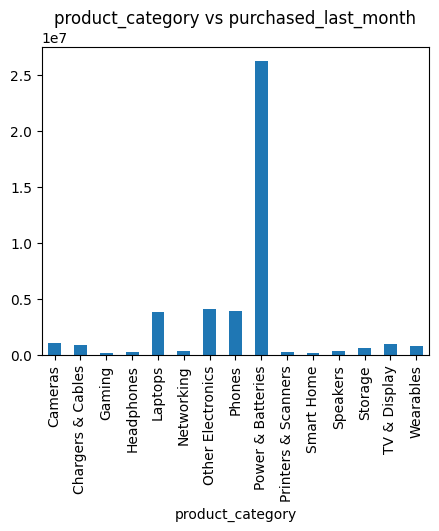

In [140]:
df.groupby(['product_category'])['purchased_last_month'].sum().plot(kind='bar',figsize=(5,4))
plt.title("product_category vs purchased_last_month")
plt.show

cat vs cat

In [141]:
df[['product_category', 'is_sponsored']].head()

,product_category,is_sponsored
0,Phones,Sponsored
1,Laptops,Sponsored
2,Laptops,Sponsored
3,Phones,Organic
4,Phones,Organic


In [142]:
pd.crosstab(index = df["is_sponsored"], columns = df["product_category"] )

product_category,Cameras,Chargers & Cables,Gaming,Headphones,Laptops,Networking,Other Electronics,Phones,Power & Batteries,Printers & Scanners,Smart Home,Speakers,Storage,TV & Display,Wearables
is_sponsored,,,,,,,,,,,,,,,
Organic,3109,1573,797,798,8061,837,8568,5190,1339,877,456,1119,1097,1407,436
Sponsored,568,260,12,199,632,233,187,1373,1538,0,9,226,533,1223,18


**Observation:Organic listings dominate across most product categories, indicating that sellers primarily rely on organic reach. However, categories like Power & Batteries and TV & Display show a relatively higher number of sponsored products, suggesting intense competition and greater reliance on paid promotion. Some categories such as Gaming and Smart Home have very low sponsored presence, indicating potential opportunities for cost-effective advertising.”

num vs num

In [143]:
df[['product_rating', 'purchased_last_month']].head()

,product_rating,purchased_last_month
0,4.6,300
1,4.3,6000
2,4.6,2000
3,4.6,10000
4,4.8,10000


In [144]:
df[['product_rating', 'purchased_last_month']].corr()

,product_rating,purchased_last_month
product_rating,1.000000,0.134106
purchased_last_month,0.134106,1.000000


observation:The correlation between product rating and purchases is very weak (0.13), indicating that rating alone does not significantly influence purchase behavior. This suggests that other features such as pricing, promotions, or product visibility play a more critical role in driving sales.”

**Multi-variate analysis**

In [145]:
df[['product_category','is_sponsored', 'purchased_last_month']].head(2)

,product_category,is_sponsored,purchased_last_month
0,Phones,Sponsored,300
1,Laptops,Sponsored,6000


In [150]:
pd.pivot_table(df,index = ["product_category"],
                   columns = ["is_sponsored"],
                   values = ["estimated_revenue", "total_reviews"],aggfunc="median")

estimated_revenue           total_reviews          
is_sponsored                  Organic Sponsored       Organic Sponsored
product_category                                                       
Cameras                       15999.0   59800.0         358.0      30.0
Chargers & Cables              9998.0    7198.0         202.0      30.0
Gaming                        13798.0   61998.0        1110.0   28293.0
Headphones                    11200.0    6249.5         883.0      76.0
Laptops                       19990.0   26378.0         182.0     343.0
Networking                    17997.5   31998.0         328.0      24.0
Other Electronics             10797.5   80198.0         376.0       6.0
Phones                        11876.0   26904.0         925.0    3510.0
Power & Batteries              7648.0  393800.0        2109.0    5207.0
Printers & Scanners            8005.0       NaN         801.0       NaN
Smart Home                    86038.0   79998.0         198.0       2.0
Speakers                      12995.0   35998.0         322.0      45.0
Storage                       15686.0   11998.0         340.0       7.0
TV & Display                  11992.0   17198.0         288.0      29.0
Wearables                      8499.0  296400.0        1320.0   24144.0

observation:Sponsored products generally outperform organic listings in both revenue and review counts, especially in high-demand categories like Power & Batteries and Wearables. However, some categories such as Cameras and Headphones perform better organically, indicating category-specific customer behavior. The data also shows strong skewness and outliers, suggesting the need for transformation before modeling.”